In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [92]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [93]:
print("Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (20640, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [94]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [96]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [97]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [98]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression RMSE: 0.7455813830127764
Linear Regression R2 Score: 0.5757877060324508


In [99]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2 Score:", ridge_r2)

Ridge Regression RMSE: 0.7455567442814779
Ridge Regression R2 Score: 0.5758157428913684


In [100]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree RMSE: 0.7021307589812817
Decision Tree R2 Score: 0.6237910370780425


In [101]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree Regressor"
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        dt_rmse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        dt_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree Regressor,0.702131,0.623791


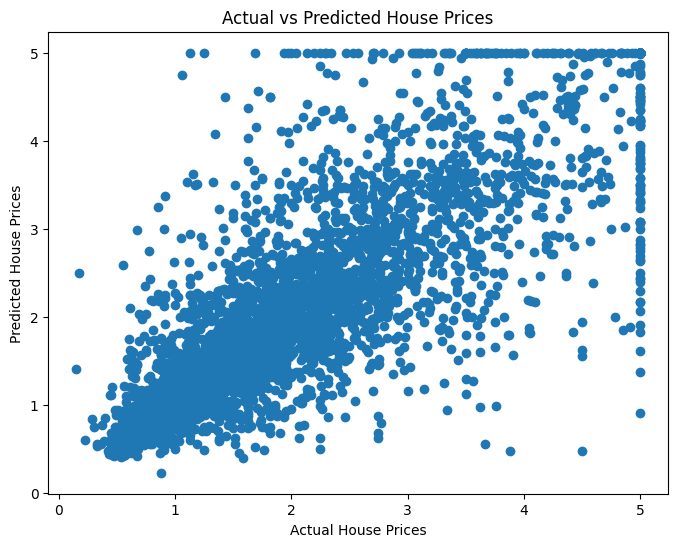

In [102]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

Best Model Selection

Among the three models tested, the Decision Tree Regressor achieved the best performance with the lowest RMSE (0.702131) and the highest R² Score (0.623791). Therefore, it was selected as the best-performing model for house price prediction.

Conclusion

In this project, the California Housing Dataset was used to predict house prices. Feature scaling was applied using StandardScaler to improve model performance. Three machine learning models—Linear Regression, Ridge Regression, and Decision Tree Regressor—were trained and evaluated using RMSE and R² Score. After comparing the results, the Decision Tree Regressor achieved the best predictive performance with the lowest RMSE and highest R² Score. This project demonstrates the importance of feature engineering and model comparison in machine learning.